# Ridge matching for stereo contrail height

**Question.** The map product estimates height by maximising the correlation of a
25 km moving window between the two views. A contrail is a *line*, and a line's
cross-section can be localised far better than the sampling interval. Does
matching the ridge itself beat matching the box that contains it?

**Three arms**, deliberately separating *support* from *estimator*:

| arm | support | estimator |
|---|---|---|
| 1 — **window** (baseline) | 25 km box, every pixel | argmax over h of windowed Pearson r |
| 2 — **ribbon** (control) | ridge-following strip | argmax over h of masked Pearson r |
| 3 — **ridge** (the method) | same strip, averaged along the trail | sub-pixel cross-ridge offset, converted to h |

Arm 2 is the control that matters. If arm 3 beats arm 1 but arm 2 does too, the
gain came from *not looking at the surrounding cirrus*, not from the estimator.

**Scope.** Ridges are placed by hand here. Automated ridge detection is
deliberately not implemented — see the last section for what it would need to
supply. Everything is developed in this notebook; nothing is added to the
package until a lever survives multiple scenes (the psf / wedge / window threads
each looked transformative on one scene and evaporated on six).

**Geometry, in one line.** A feature at true height $h_t$ rendered at assumed
height $h_a$ appears displaced by $(h_t-h_a)\,\mathbf{k}$, where
$\mathbf{k} = \partial(\mathbf{D}_E - \mathbf{D}_W)/\partial h$ is the
differential parallax vector. A line only constrains the component *across*
itself, so the observable is

$$\delta_\perp = (h_t - h_a)\,(\mathbf{k}\cdot\hat{n}), \qquad
  h_t = h_a + \delta_\perp / (\mathbf{k}\cdot\hat{n}).$$

$s \equiv \mathbf{k}\cdot\hat{n}$ (km of offset per km of height) is the
**sensitivity**. It is computable from geometry alone, before any matching, and
it goes to zero for a trail parallel to $\mathbf{k}$ — the aperture problem.

## 1. Setup

In [154]:
import os, sys
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.ndimage import map_coordinates
import rioxarray as rxr

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(ROOT, "src"))
sys.path.insert(0, os.path.join(ROOT, "tests"))

from contrailstereo.config import DEFAULT, SAT_LON
from contrailstereo.geometry import build_grid, km_filters, apparent_surface_latlon
from contrailstereo.core.fields import make_sampler
from contrailstereo.core.match import project_pair
from contrailstereo.core.peaks import refine_peak
from contrailstereo.core.retrieve import load_scene, run_scene

cfg = DEFAULT
print("config", cfg.config_hash(), "| match", cfg.match_channels,
      "| win_km", cfg.win_km, "| hp_sigma_km", cfg.hp_sigma_km)

config db66cff6a0 | match (13, 15) | win_km 25.0 | hp_sigma_km 8.0


### Scene

Fixture scenes (0, 8, 12, 41, 46) run with no network and are the fastest way to
iterate. Set `USE_FIXTURE = False` and point `NC_PATH` at the collocations file
to work on any scene from the table.

Fixture scene 8 is the easiest scene in the suite (r_local 0.90, map_scatter
0.39) and has a dense set of clean linear contrails. That makes it a good
scene to *develop* on and a bad scene to *conclude* from — the window baseline
is already near its ceiling here. Scene 0 (r_local 0.73, map_scatter 0.57,
VZA 66°) is the harder second case.

In [194]:
USE_FIXTURE = False
SCENE       = 0
NC_PATH     = "/Users/lewisclark/Documents/python_work/stereo/data/collocations.nc"

if USE_FIXTURE:
    from conftest import load_fixture_scene
    sd = load_fixture_scene(SCENE)
else:
    from contrailstereo.data.caliop import build_scene_table
    scenes, prof_df = build_scene_table(NC_PATH)
    sd = load_scene(scenes.iloc[SCENE], prof_df, cfg)

a, b = cfg.match_channels
samplers = {s: make_sampler(sd.fields[s][a], sd.fields[s][b])
            for s in (cfg.sat_east, cfg.sat_west)}
glat, glon, px = build_grid(sd.profiles, cfg)
sig, win = km_filters(px, cfg)
lat0, lon0 = sd.lat0, sd.lon0
LA, LO = glat[:, 0], glon[0, :]

print(f"scene {SCENE}  {sd.when}  ({lat0:.2f}, {lon0:.2f})")
print(f"grid {glat.shape}  px {px[0]:.2f}/{px[1]:.2f} km  win {win} px")
print(f"offset {sd.offset_s:+.2f} s  wind correction: {sd.winds is not None}")
print(f"{len(sd.profiles)} CALIOP profiles, top {sd.profiles.top_km.median():.2f} km")

scene 0  2019-04-17 21:26:15  (40.71, -121.56)
grid (750, 296)  px 1.07/1.00 km  win (23, 25) px
offset +0.98 s  wind correction: False
319 CALIOP profiles, top 12.31 km


In [195]:

EXTRA_CHANNELS = (14,)      # diagnostics only; the retrieval uses cfg.match_channels

def ensure_channels(sd, channels):
    """Load channels the retrieval doesn't need but the diagnostics do."""
    for sat in (cfg.sat_east, cfg.sat_west):
        for ch in channels:
            if ch in sd.fields[sat]:
                continue
            if USE_FIXTURE:
                from conftest import FIXDIR
                p_ = os.path.join(FIXDIR, f"scene_{SCENE:04d}", f"G{sat}_C{ch:02d}.nc")
                if not os.path.exists(p_):
                    print(f"  no fixture for G{sat} C{ch:02d} - skipping")
                    continue
                sd.fields[sat][ch] = xr.open_dataset(p_)
            else:
                from contrailstereo.data.goes import fetch_channel
                sd.fields[sat][ch] = fetch_channel(sat, ch, sd.when, cfg)

ensure_channels(sd, EXTRA_CHANNELS)
print("channels available:", {s: sorted(sd.fields[s]) for s in sd.fields})

📦 Finished downloading [1] files to [/Users/lewisclark/data/noaa-goes16/ABI-L2-CMIPC].
📦 Finished downloading [1] files to [/Users/lewisclark/data/noaa-goes17/ABI-L2-CMIPC].
channels available: {16: [13, 14, 15], 17: [13, 14, 15]}


# Aside - caliop data for scene 12

In [170]:
from pyhdf.SD import SD, SDC
f = SD("/Users/lewisclark/Documents/python_work/stereo/data/CAL_LID_L2_05kmCLay-Standard-V4-51.2019-04-10T19-43-27ZD.hdf", SDC.READ)
for k, (dims, shape, typ, _) in sorted(f.datasets().items()):
    print(f"{k:45s} {shape}")

Attenuated_Backscatter_Statistics_1064        (3456, 60)
Attenuated_Backscatter_Statistics_532         (3456, 60)
Attenuated_Scattering_Ratio_Statistics_532    (3456, 60)
Attenuated_Total_Color_Ratio_Statistics       (3456, 60)
CAD_Score                                     (3456, 10)
Calibration_Altitude_532                      (3456, 2)
Column_Feature_Fraction                       (3456, 1)
Column_IAB_Cumulative_Probability             (3456, 1)
Column_Integrated_Attenuated_Backscatter_532  (3456, 1)
Column_Optical_Depth_Cloud_532                (3456, 1)
Column_Optical_Depth_Cloud_Uncertainty_532    (3456, 1)
Column_Optical_Depth_Stratospheric_Aerosols_1064 (3456, 1)
Column_Optical_Depth_Stratospheric_Aerosols_532 (3456, 1)
Column_Optical_Depth_Stratospheric_Aerosols_Uncertainty_1064 (3456, 1)
Column_Optical_Depth_Stratospheric_Aerosols_Uncertainty_532 (3456, 1)
Column_Optical_Depth_Tropospheric_Aerosols_1064 (3456, 1)
Column_Optical_Depth_Tropospheric_Aerosols_532 (3456, 1)
Column

In [186]:
from pyhdf.SD import SD, SDC
f = SD("/Users/lewisclark/Documents/python_work/stereo/data/CAL_LID_L1-Standard-V4-51.2019-04-10T19-43-27ZD.hdf", SDC.READ)
for k, (dims, shape, typ, _) in sorted(f.datasets().items()):
    print(f"{k:45s} {shape}")

Amplifier_Gain_1064                           (55590, 1)
Attenuated_Backscatter_1064                   (55590, 583)
Calibration_Constant_1064                     (55590, 1)
Calibration_Constant_532                      (55590, 1)
Calibration_Constant_Uncertainty_1064         (55590, 1)
Calibration_Constant_Uncertainty_532          (55590, 1)
Day_Night_Flag                                (55590, 1)
Depolarization_Gain_Ratio_532                 (55590, 1)
Depolarization_Gain_Ratio_Uncertainty_532     (55590, 1)
Earth-Sun_Distance                            (55590, 1)
Frame_Number                                  (55590, 1)
GMAO_Surface_Elevation                        (55590, 1)
IGBP_Surface_Type                             (55590, 1)
Land_Water_Mask                               (55590, 1)
Laser_Energy_1064                             (55590, 1)
Laser_Energy_532                              (55590, 1)
Latitude                                      (55590, 1)
Lidar_Mode                   

In [181]:
import numpy as np, pandas as pd
from pyhdf.SD import SD, SDC

def read_clay(path):
    f = SD(path, SDC.READ)
    g = lambda n: f.select(n)[:]
    lat, lon = g("Latitude"), g("Longitude")          # (nprof, 3): first/mid/last shot
    nlay = g("Number_Layers_Found").ravel()
    top  = np.where(g("Layer_Top_Altitude")  < -999, np.nan, g("Layer_Top_Altitude"))
    base = np.where(g("Layer_Base_Altitude") < -999, np.nan, g("Layer_Base_Altitude"))
    od   = np.where(g("Feature_Optical_Depth_532") < -999, np.nan,
                    g("Feature_Optical_Depth_532"))
    fcf  = g("Feature_Classification_Flags").astype(np.uint16)
    t    = g("Profile_UTC_Time")[:, 1]                # yymmdd.fraction_of_day
    ttop = np.where(g("Layer_Top_Temperature") < -999, np.nan,
                    g("Layer_Top_Temperature")) + 273.15      # file is degC -> K
    opq  = g("Opacity_Flag")                                  # 0 transparent, 1 opaque
    cad  = g("CAD_Score")                                     # -100..100, |100| = confident
    f.end()

    d = np.floor(t); yy = np.floor(d / 10000)
    mm = np.floor((d - yy * 10000) / 100); dd = d - yy * 10000 - mm * 100
    when = (pd.to_datetime(dict(year=(2000 + yy).astype(int),
                                month=mm.astype(int), day=dd.astype(int)))
            + pd.to_timedelta(t - d, unit="D"))

    rows = []
    for i in range(len(nlay)):
        for j in range(int(nlay[i])):
            rows.append(dict(prof=i, time=when[i], lat=lat[i, 1], lon=lon[i, 1],
                             layer=j, n_layers=int(nlay[i]),
                             top_km=top[i, j], base_km=base[i, j], od532=od[i, j],
                             ftype=fcf[i, j] & 0b111,          # 2 = cloud
                             phase=(fcf[i, j] >> 5) & 0b11,    # 1 = ice, 2 = water
                             subtype=(fcf[i, j] >> 9) & 0b111,
                                                          top_k=ttop[i, j],
                             opaque=int(opq[i, j]),
                             cad=int(cad[i, j]),))
    return pd.DataFrame(rows)

In [199]:
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

CLAY_PATH = "/Users/lewisclark/Documents/python_work/stereo/data/CAL_LID_L2_05kmCLay-Standard-V4-51.2019-04-10T19-43-27ZD.hdf"
cl = read_clay(CLAY_PATH)

# subset the half-orbit to this scene's track
lat_lo, lat_hi = sd.profiles.lat.min(), sd.profiles.lat.max()
lon_lo, lon_hi = sd.profiles.lon.min(), sd.profiles.lon.max()
cl = cl[(cl.lat.between(lat_lo - 0.1, lat_hi + 0.1))
        & (cl.lon.between(lon_lo - 2.0, lon_hi + 2.0))
        & (cl.ftype == 2)].copy()                       # clouds only
print(f"{cl.prof.nunique()} CALIPSO 5 km columns, {len(cl)} cloud layers, "
      f"lat {cl.lat.min():.2f}-{cl.lat.max():.2f}")

def pick(df, *candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"none of {candidates} in frame; have: {list(df.columns)}")

od_col = pick(cl, "od532", "feature_optical_depth_532", "Feature_Optical_Depth_532",
                  "iab532", "integrated_attenuated_backscatter_532",
                  "Integrated_Attenuated_Backscatter_532")
base_col = pick(cl, "base_km", "layer_base_altitude", "Layer_Base_Altitude")
print(f"colouring by {od_col}, base from {base_col}")

v = cl[od_col].to_numpy(float)
v = v[np.isfinite(v) & (v > 0)]
if v.size == 0:
    raise ValueError(f"{od_col} is all NaN or non-positive - check the fill masking")
norm = LogNorm(vmin=max(np.percentile(v, 2), 1e-3), vmax=np.percentile(v, 98))
sm = ScalarMappable(norm=norm, cmap="plasma")
trk = prof.sort_values("lat")

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                        gridspec_kw=dict(height_ratios=[3, 1, 1]))

ax = axs[0]
ax.vlines(cl.lat, cl[base_col], cl.top_km, colors=sm.to_rgba(cl[od_col]),
          lw=2.5, zorder=1)
ax.plot(sd.profiles.lat, sd.profiles.top_km, ".", ms=3, color="magenta",
        zorder=3, label="collocation top_altitude")
ax.plot(trk.lat, trk.h_map, ".", ms=3, color="#1f4e8c", zorder=3, label="arm 1 stereo")
if "h_ridge" in trk:
    ax.plot(trk.lat, trk.h_ridge, "D", ms=4, ls="none", color="C3", zorder=4,
            label="arm 3 ridge")
cb = fig.colorbar(sm, ax=ax, pad=0.01); cb.set_label(od_col.replace("_", " "))
ax.set_ylabel("altitude [km]"); ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
ax.set_title("CALIPSO cloud layers (bar = base to top) with the stereo retrievals",
             fontsize=10)

ax = axs[1]
nl = cl.groupby("prof").agg(lat=("lat", "first"), n=("n_layers", "first"))
ax.step(nl.lat, nl.n, where="mid", color="k", lw=1)
ax.set_ylabel("n layers"); ax.grid(alpha=0.3); ax.set_ylim(0, nl.n.max() + 0.5)

ax = axs[2]
topmost = cl.sort_values(["prof", "layer"]).groupby("prof").first()
ax.semilogy(topmost.lat, topmost[od_col], ".", ms=4, color="C2")
if "opacity_flag" in cl:
    op = cl.groupby("prof").opacity_flag.max()
    ax.plot(topmost.lat[op.values == 1], topmost[od_col][op.values == 1], "x",
            ms=6, color="r", label="opaque column")
    ax.legend(fontsize=8)
ax.set_ylabel("top layer\noptical depth")
ax.set_xlabel("latitude [$\\degree$N]"); ax.grid(alpha=0.3)
plt.tight_layout()

# --- containment: does the retrieval land inside any detected layer? ---------
cols = cl.groupby("prof").agg(lat=("lat", "first"), lon=("lon", "first"))
lay = {p: g[["top_km", base_col]].values for p, g in cl.groupby("prof")}

def contained(lat, lon, h, pad=0.06):
    if not np.isfinite(h):
        return np.nan
    k = int(np.argmin(np.hypot(cols.lat - lat, (cols.lon - lon) * 0.7)))
    L = lay[cols.index[k]]
    return float(np.any((h <= L[:, 0] + pad) & (h >= L[:, 1] - pad)))

for col, lab in (("h_map", "arm 1 window"), ("h_ridge", "arm 3 ridge")):
    if col not in trk:
        continue
    c = np.array([contained(r.lat, r.lon, getattr(r, col)) for r in trk.itertuples()],
                 float)
    c = c[np.isfinite(c)]
    if c.size:
        print(f"{lab:16s}: inside a detected layer for {c.mean():.0%} of {c.size}")
c = np.array([contained(r.lat, r.lon, r.top_km) for r in sd.profiles.itertuples()])
print(f"{'collocation top':16s}: {np.nanmean(c):.0%}  (sanity check, expect ~100%)")

0 CALIPSO 5 km columns, 0 cloud layers, lat nan-nan
colouring by od532, base from base_km


ValueError: od532 is all NaN or non-positive - check the fill masking

1789 L1 profiles, lat 43.60-48.90, along-track step 329 m


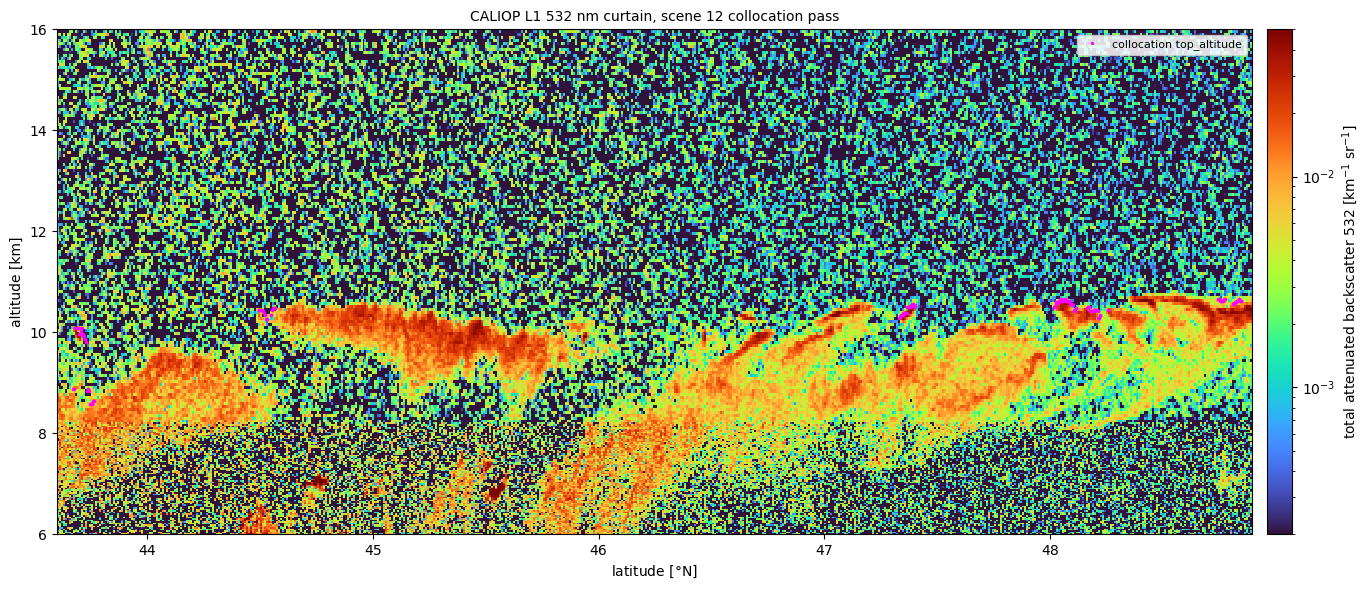

In [193]:
# --- CALIOP L1 attenuated backscatter curtain -------------------------------
# 333 m along track -- the same sampling as the collocation profiles, so this is
# the curtain the collocation's top_altitude was derived from.
from matplotlib.colors import LogNorm
from pyhdf.SD import SD, SDC

L1_PATH   = "/Users/lewisclark/Documents/python_work/stereo/data/CAL_LID_L1-Standard-V4-51.2019-04-10T19-43-27ZD.hdf"
LAT_RANGE = (43.6, 48.9)
ALT_RANGE = (6.0, 16.0)
SMOOTH    = 3          # average this many profiles (3 -> ~1 km); display only

def lidar_altitudes(path=None):
    """583-bin L1 altitude grid [km], descending. Vertical resolution is
    60 m between 8.2 and 20.2 km and 30 m below 8.2 km -- NOT uniform."""
    if path:
        try:
            from pyhdf.HDF import HDF, HC
            import pyhdf.VS                      # registers HDF.vstart
            h = HDF(path, HC.READ); vs = h.vstart()
            vd = vs.attach(vs.find("metadata")); rec = vd.read(1)[0]
            a = np.asarray(rec[vd._fields.index("Lidar_Data_Altitudes")], float)
            vd.detach(); vs.end(); h.close()
            if a.size == 583:
                return a
        except Exception as e:
            print(f"metadata read failed ({e}); falling back to the standard grid")
    spec = [(40.0, 30.1, 0.300), (30.1, 20.2, 0.180), (20.2, 8.2, 0.060),
            (8.2, -0.5, 0.030), (-0.5, -2.0, 0.300)]
    return np.concatenate([hi - dz * (np.arange(int(round((hi - lo) / dz))) + 0.5)
                           for hi, lo, dz in spec])

alt = lidar_altitudes(L1_PATH)

f = SD(L1_PATH, SDC.READ)
lat_all = f.select("Latitude")[:, 0]
lon_all = f.select("Longitude")[:, 0]
lon_lo, lon_hi = sd.profiles.lon.min(), sd.profiles.lon.max()
m = ((lat_all >= LAT_RANGE[0]) & (lat_all <= LAT_RANGE[1])
     & (lon_all > lon_lo - 3) & (lon_all < lon_hi + 3))
if not m.any():
    f.end()
    raise ValueError("no L1 profiles in range - wrong granule, or the orbit "
                     "crosses this band on the other side of the globe")
i0, i1 = (int(v) for v in np.where(m)[0][[0, -1]])      # pyhdf needs plain ints
beta = f.select("Total_Attenuated_Backscatter_532")[i0:i1 + 1, :].astype(float)
lat = lat_all[i0:i1 + 1]
f.end()
print(f"{beta.shape[0]} L1 profiles, lat {lat.min():.2f}-{lat.max():.2f}, "
      f"along-track step {np.median(np.abs(np.diff(lat))) * 111 * 1e3:.0f} m")

kz = (alt >= ALT_RANGE[0]) & (alt <= ALT_RANGE[1])
Z, zz = beta[:, kz], alt[kz]
if SMOOTH > 1:
    n = (Z.shape[0] // SMOOTH) * SMOOTH
    Z = Z[:n].reshape(-1, SMOOTH, Z.shape[1]).mean(1)
    lat_p = lat[:n].reshape(-1, SMOOTH).mean(1)
else:
    lat_p = lat

fig, ax = plt.subplots(figsize=(15, 6))
pm = ax.pcolormesh(lat_p, zz, np.clip(Z, 1e-4, None).T,
                   norm=LogNorm(vmin=2e-4, vmax=5e-2), cmap="turbo", shading="nearest")
cb = fig.colorbar(pm, ax=ax, pad=0.01)
cb.set_label("total attenuated backscatter 532 [km$^{-1}$ sr$^{-1}$]")

ax.plot(sd.profiles.lat, sd.profiles.top_km, ".", ms=3, color="magenta",
        label="collocation top_altitude")
#_t = trk if "h_ridge" in globals().get("trk", {}) else prof.sort_values("lat")
#ax.plot(_t.lat, _t.h_map, ".", ms=3, color="w", label="arm 1 stereo")
#if "h_ridge" in _t:
#    ax.plot(_t.lat, _t.h_ridge, "D", ms=4, ls="none", mec="k", mfc="none",
#            label="arm 3 ridge")
#if "cl" in dir():                                # L2 layer bounds, if loaded
#    ax.plot(cl.lat, cl.top_km, "_", ms=5, color="k")
#    ax.plot(cl.lat, cl[base_col], "_", ms=5, color="0.4")

ax.set_ylim(*ALT_RANGE)
ax.set_xlabel("latitude [$\\degree$N]"); ax.set_ylabel("altitude [km]")
ax.legend(fontsize=8, loc="upper right", framealpha=0.85)
ax.set_title(f"CALIOP L1 532 nm curtain, scene {SCENE} collocation pass", fontsize=10)
plt.tight_layout()

## 2. Arm 1 — the 25 km window baseline

Straight from the package, unmodified. `Hq` is the per-pixel height map and
`rmax` its peak local correlation; both are sampled later at the ridge bin
centres so the arms are compared at *identical locations*.

In [107]:
rec, prof, ex = run_scene(sd, cfg, do_map=True)
Hq, rmax = ex["Hq"], ex["rmax"]

print(f"qc={rec['qc']}  h_local={rec['h_local']:.2f}  r_local={rec['r_local']:.2f}")
print(f"map: n={rec['map_n']}  bias={rec['map_bias']:+.3f}  "
      f"scatter={rec['map_scatter']:.3f}  coverage={rec['map_coverage']:.2f}")
print(f"VZA east/west = {rec['vza_east']:.1f} / {rec['vza_west']:.1f}")

qc=ok  h_local=10.21  r_local=0.87
map: n=161  bias=-0.232  scatter=0.328  coverage=0.48
VZA east/west = 62.9 / 62.2


## 3. Local frame, sampling, and the disparity vector

A local equirectangular km frame anchored at the scene centre. Everything
below — ridge geometry, transverse offsets, sensitivity — lives in it.

In [108]:
KMLON = 111.0 * np.cos(np.deg2rad(lat0))

def to_km(lat, lon):
    """(lat, lon) -> (x east, y north) km about the scene centre."""
    return ((np.asarray(lon, float) - lon0) * KMLON,
            (np.asarray(lat, float) - lat0) * 111.0)

def to_ll(x, y):
    return (lat0 + np.asarray(y, float) / 111.0,
            lon0 + np.asarray(x, float) / KMLON)

def sample(F, lat, lon):
    """Bilinear sample of a grid field at (lat, lon); NaN off-grid."""
    i = (np.atleast_1d(np.asarray(lat, float)) - LA[0]) / (LA[1] - LA[0])
    j = (np.atleast_1d(np.asarray(lon, float)) - LO[0]) / (LO[1] - LO[0])
    return map_coordinates(F, [i, j], order=1, mode="constant", cval=np.nan)

def disparity_k(lat, lon, h=12.0):
    """Differential parallax vector [km per km of height], (dx, dy).

    D_E(h) - D_W(h) divided by h, using the package's ray-ellipsoid
    projection so it stays consistent with project_pair.
    """
    o = []
    for s in (cfg.sat_east, cfg.sat_west):
        al, ao = apparent_surface_latlon(lat, lon, h * 1e3, SAT_LON[s])
        o.append(np.array([(ao - lon) * 111.0 * np.cos(np.deg2rad(lat)),
                           (al - lat) * 111.0]))
    return (o[0] - o[1]) / h

The conversion $h_t = h_a + \delta_\perp/s$ assumes $\mathbf{k}$ is constant in
$h$ and across the grid. Check both before relying on it — if either fails, the
one-shot linear inversion has to become an iteration.

In [109]:
print("linearity in h:")
for h in (8.0, 11.0, 14.0):
    k = disparity_k(lat0, lon0, h)
    print(f"  h={h:4.1f}  k=({k[0]:+.4f}, {k[1]:+.4f})  |k|={np.hypot(*k):.4f}  "
          f"az={np.degrees(np.arctan2(k[1], k[0])):.2f} deg")

print("variation across the grid (h=12):")
for la, lo in [(glat.min(), glon.min()), (glat.max(), glon.max()), (lat0, lon0)]:
    k = disparity_k(la, lo, 12.0)
    print(f"  ({la:6.2f},{lo:8.2f})  |k|={np.hypot(*k):.4f}  "
          f"az={np.degrees(np.arctan2(k[1], k[0])):.2f} deg")

linearity in h:
  h= 8.0  k=(-2.4404, +0.0083)  |k|=2.4404  az=179.80 deg
  h=11.0  k=(-2.4450, +0.0084)  |k|=2.4450  az=179.80 deg
  h=14.0  k=(-2.4495, +0.0084)  |k|=2.4495  az=179.80 deg
variation across the grid (h=12):
  ( 43.37, -107.96)  |k|=2.1888  az=179.61 deg
  ( 49.15, -104.63)  |k|=2.5267  az=-179.56 deg
  ( 48.02, -106.93)  |k|=2.4465  az=179.80 deg


## 4. Ridge representation

A ridge is a polyline of hand-placed `(lat, lon)` vertices. It is resampled at
uniform arc length, given a unit tangent and left normal at every sample, and
split into along-trail bins. Averaging the transverse profiles inside a bin is
where the precision comes from: $N$ quasi-independent cross-sections localise
the centre roughly $\sqrt{N}$ better than one.

Note what the polyline does **not** have to be: exactly on the crest. The
measurement is differential — both views are sampled on the same
$\hat{n}$ at the same $s$ — so an offset polyline only costs window coverage.
Its *orientation* does matter, because $\hat{n}$ sets both the observable and the
sensitivity.

In [110]:
def resample_ridge(vertices, ds_km=2.0):
    """[(lat, lon), ...] -> arc-length samples with unit tangent and normal."""
    x, y = to_km(*np.array(vertices, float).T)
    s = np.concatenate([[0], np.cumsum(np.hypot(np.diff(x), np.diff(y)))])
    su = np.arange(0, s[-1] + 1e-9, ds_km)
    xs, ys = np.interp(su, s, x), np.interp(su, s, y)
    tx, ty = np.gradient(xs), np.gradient(ys)
    n = np.hypot(tx, ty)
    tx, ty = tx / n, ty / n
    return dict(s=su, x=xs, y=ys, tx=tx, ty=ty, nx=-ty, ny=tx)

def ridge_bins(R, bin_km):
    """Split a ridge into along-trail bins; one height estimate per bin."""
    e = np.arange(R["s"][0], R["s"][-1] + bin_km, bin_km)
    idx = np.clip(np.digitize(R["s"], e) - 1, 0, len(e) - 2)
    out = []
    for k in range(len(e) - 1):
        m = idx == k
        if m.sum() >= 2:
            out.append(dict(m=m, s=float(R["s"][m].mean()),
                            x=float(R["x"][m].mean()), y=float(R["y"][m].mean()),
                            nx=float(R["nx"][m].mean()), ny=float(R["ny"][m].mean()),
                            n_pts=int(m.sum())))
    return out

def transverse(F, R, half_km, dsn_km=0.5):
    """Profiles across the ridge: (n_samples, n_transverse) + the offset axis."""
    sn = np.arange(-half_km, half_km + 1e-9, dsn_km)
    X = R["x"][:, None] + R["nx"][:, None] * sn[None, :]
    Y = R["y"][:, None] + R["ny"][:, None] * sn[None, :]
    la, lo = to_ll(X, Y)
    return sample(F, la, lo).reshape(X.shape), sn

## 5. The estimator (arm 3)

For each bin: average the transverse profiles in both views, scan the lag
$\lambda$, and take the peak of the normalised correlation
$r(\lambda) = \mathrm{corr}\big(p_A(s),\, p_B(s-\lambda)\big)$, which is maximal
at $\lambda = \delta_\perp$.

Three choices that are not free:

- **The lag search is bounded** to $|\lambda| \le |s|\,\Delta h_{max}$. Unbounded
  correlation on a multi-ridge scene locks onto a neighbouring trail; this is the
  same failure that produced 4–6 km excursions in the Sentinel-2 retrieval.
- **Peak refinement reuses `refine_peak`** from the package, fitted in $\lambda$
  and converted, so `sigma_h` carries the same meaning (and the same documented
  underdispersion) as the scene-mode error bar.
- **No detrending.** See the synthetic test below — this one is a trap.

In [111]:
def lag_curve(pA, pB, sn, lam):
    """Normalised correlation of pA(s) against pB(s - lam), over a fixed window."""
    r = np.full(lam.size, np.nan)
    keep = np.abs(sn) <= sn.max() - np.abs(lam).max()   # same support at every lag
    for q, L in enumerate(lam):
        pBs = np.interp(sn - L, sn, pB, left=np.nan, right=np.nan)
        m = keep & np.isfinite(pA) & np.isfinite(pBs)
        if m.sum() < 8:
            continue
        u, v = pA[m] - pA[m].mean(), pBs[m] - pBs[m].mean()
        d = np.sqrt((u @ u) * (v @ v))
        if d > 0:
            r[q] = (u @ v) / d
    return r


def ridge_arm(A, B, R, h_ref, half_km=9.0, bin_km=20.0, dh_max=3.0,
              polarity=1, dlam_km=0.05, lam_fit_km=1.0, detrend=False):
    """Arm 3: per-bin height from the sub-pixel cross-ridge offset."""
    PA, sn = transverse(A, R, half_km)
    PB, _ = transverse(B, R, half_km)
    PA, PB = polarity * PA, polarity * PB
    if detrend:                                    # kept only for the demo below
        for P in (PA, PB):
            u = np.arange(P.shape[1], dtype=float)
            for q in range(P.shape[0]):
                m = np.isfinite(P[q])
                if m.sum() > 4:
                    P[q] -= np.polyval(np.polyfit(u[m], P[q][m], 1), u)
    rows = []
    for bn in ridge_bins(R, bin_km):
        la, lo = (float(v) for v in to_ll(bn["x"], bn["y"]))
        k = disparity_k(la, lo, h_ref)
        sens = k[0] * bn["nx"] + k[1] * bn["ny"]           # km offset per km height
        lam_max = min(abs(sens) * dh_max, 0.6 * half_km)
        lam = np.arange(-lam_max, lam_max + 1e-9, dlam_km)
        with np.errstate(invalid="ignore"):
            qA = np.nanmean(PA[bn["m"]], axis=0)
            qB = np.nanmean(PB[bn["m"]], axis=0)
        r = lag_curve(qA, qB, sn, lam)
        if not np.isfinite(r).any():
            continue
        lpk, rpk, s_lam = refine_peak(lam, r, lam[int(np.nanargmax(r))],
                                      halfwidth=lam_fit_km)
        ok = abs(sens) > 1e-3
        rows.append(dict(
            s=bn["s"], lat=la, lon=lo, n_pts=bn["n_pts"], sens=float(sens),
            d_perp=lpk, r=rpk,
            h=(h_ref + lpk / sens) if ok else np.nan,
            sigma_h=(s_lam / abs(sens)) if (ok and np.isfinite(s_lam)) else np.nan,
            amp=float(np.nanmax(qA) - np.nanmedian(qA)),
            at_edge=bool(abs(lpk) > 0.9 * lam_max),
            profA=qA, profB=qB, sn=sn, lam=lam, rcurve=r))
    return rows

## 6. Synthetic closure — before any real data

An analytic straight Gaussian ridge at a known orientation, rendered at a known
height offset. No resampling, no imagery: this tests the sign convention, the
$\delta_\perp \to h$ conversion, and nothing else.

It also catches a real trap. Linearly detrending each transverse profile is the
obvious way to remove residual background slope — and it **shrinks the retrieved
offset toward zero**, because detrending an off-centre feature over a window
displaces its peak inward. The shrinkage is proportional, so it looks like a
plausible calibration factor rather than a bug. The field is already high-passed
at 8 km, so the fix is simply not to detrend.

In [112]:
X, Y = to_km(glat, glon)
k0 = disparity_k(lat0, lon0, 13.0)

def synth_ridge(t_ang_deg, dh, w_km=3.0):
    """Straight Gaussian ridge; the feature sits at x + dh*k in the projection."""
    t = np.array([np.cos(np.deg2rad(t_ang_deg)), np.sin(np.deg2rad(t_ang_deg))])
    n = np.array([-t[1], t[0]])
    sh = dh * k0
    u = (X - sh[0]) * n[0] + (Y - sh[1]) * n[1]
    return np.exp(-0.5 * (u / w_km) ** 2)

print(f"{'t_ang':>7} {'sens':>7} {'dh_true':>8} {'no detrend':>12} {'detrended':>11}")
for ang in (-70.0, -45.0, -20.0, 0.0):
    t = np.array([np.cos(np.deg2rad(ang)), np.sin(np.deg2rad(ang))])
    verts = [tuple(float(v) for v in to_ll(-60 * t[0], -60 * t[1])),
             tuple(float(v) for v in to_ll(60 * t[0], 60 * t[1]))]
    R = resample_ridge(verts)
    A_s = synth_ridge(ang, 0.0)
    for dh in (0.5, 1.5):
        B_s = synth_ridge(ang, -dh)          # pos_A - pos_B = +dh*k
        out = {}
        for tag, det in (("plain", False), ("detr", True)):
            rr = ridge_arm(A_s, B_s, R, 13.0, detrend=det)
            out[tag] = np.nanmedian([x["h"] for x in rr]) - 13.0
        sens = np.nanmean([x["sens"] for x in ridge_arm(A_s, B_s, R, 13.0)])
        print(f"{ang:+7.1f} {sens:+7.3f} {dh:+8.2f} "
              f"{out['plain']:+8.4f} ({out['plain']/dh:5.3f}) "
              f"{out['detr']:+7.4f} ({out['detr']/dh:5.3f})")

  t_ang    sens  dh_true   no detrend   detrended
  -70.0  -2.298    +0.50  +0.5000 (1.000) +0.4119 (0.824)
  -70.0  -2.298    +1.50  +1.4998 (1.000) +1.2437 (0.829)
  -45.0  -1.725    +0.50  +0.5008 (1.002) +0.4109 (0.822)
  -45.0  -1.725    +1.50  +1.4991 (0.999) +1.2379 (0.825)
  -20.0  -0.829    +0.50  +0.5000 (1.000) +0.3538 (0.708)
  -20.0  -0.829    +1.50  +1.5001 (1.000) +1.0660 (0.711)
   +0.0  +0.009    +0.50  +0.0608 (0.122) +0.0608 (0.122)
   +0.0  +0.009    +1.50  +0.0608 (0.041) +0.0608 (0.041)


Closure to a few parts in $10^3$ at every orientation with no detrending, and a
20–35% shrinkage with it — worse the closer the ridge runs to $\mathbf{k}$,
i.e. exactly where the sensitivity is already weakest. `detrend=False` from here on.

## 7. Place the ridges

Plot the high-passed east view at a reference height, read the crests off the
grid, and write them into `RIDGES` as literal vertex lists. Literals rather than
clicks so the picks survive a kernel restart and land in version control with
the results.

`H_REF` only sets the frame in which the offset is measured; the conversion is
linear, so the answer is insensitive to it (checked in §10). Use the scene's
`h_local`.

raw C13 BT median 280.4 K
raw BTD (13, 15): median  5.60 K   p99 14.75 K   scene sd 2.80 K
raw BTD (14, 15): median  4.07 K   p99  6.63 K   scene sd 1.00 K


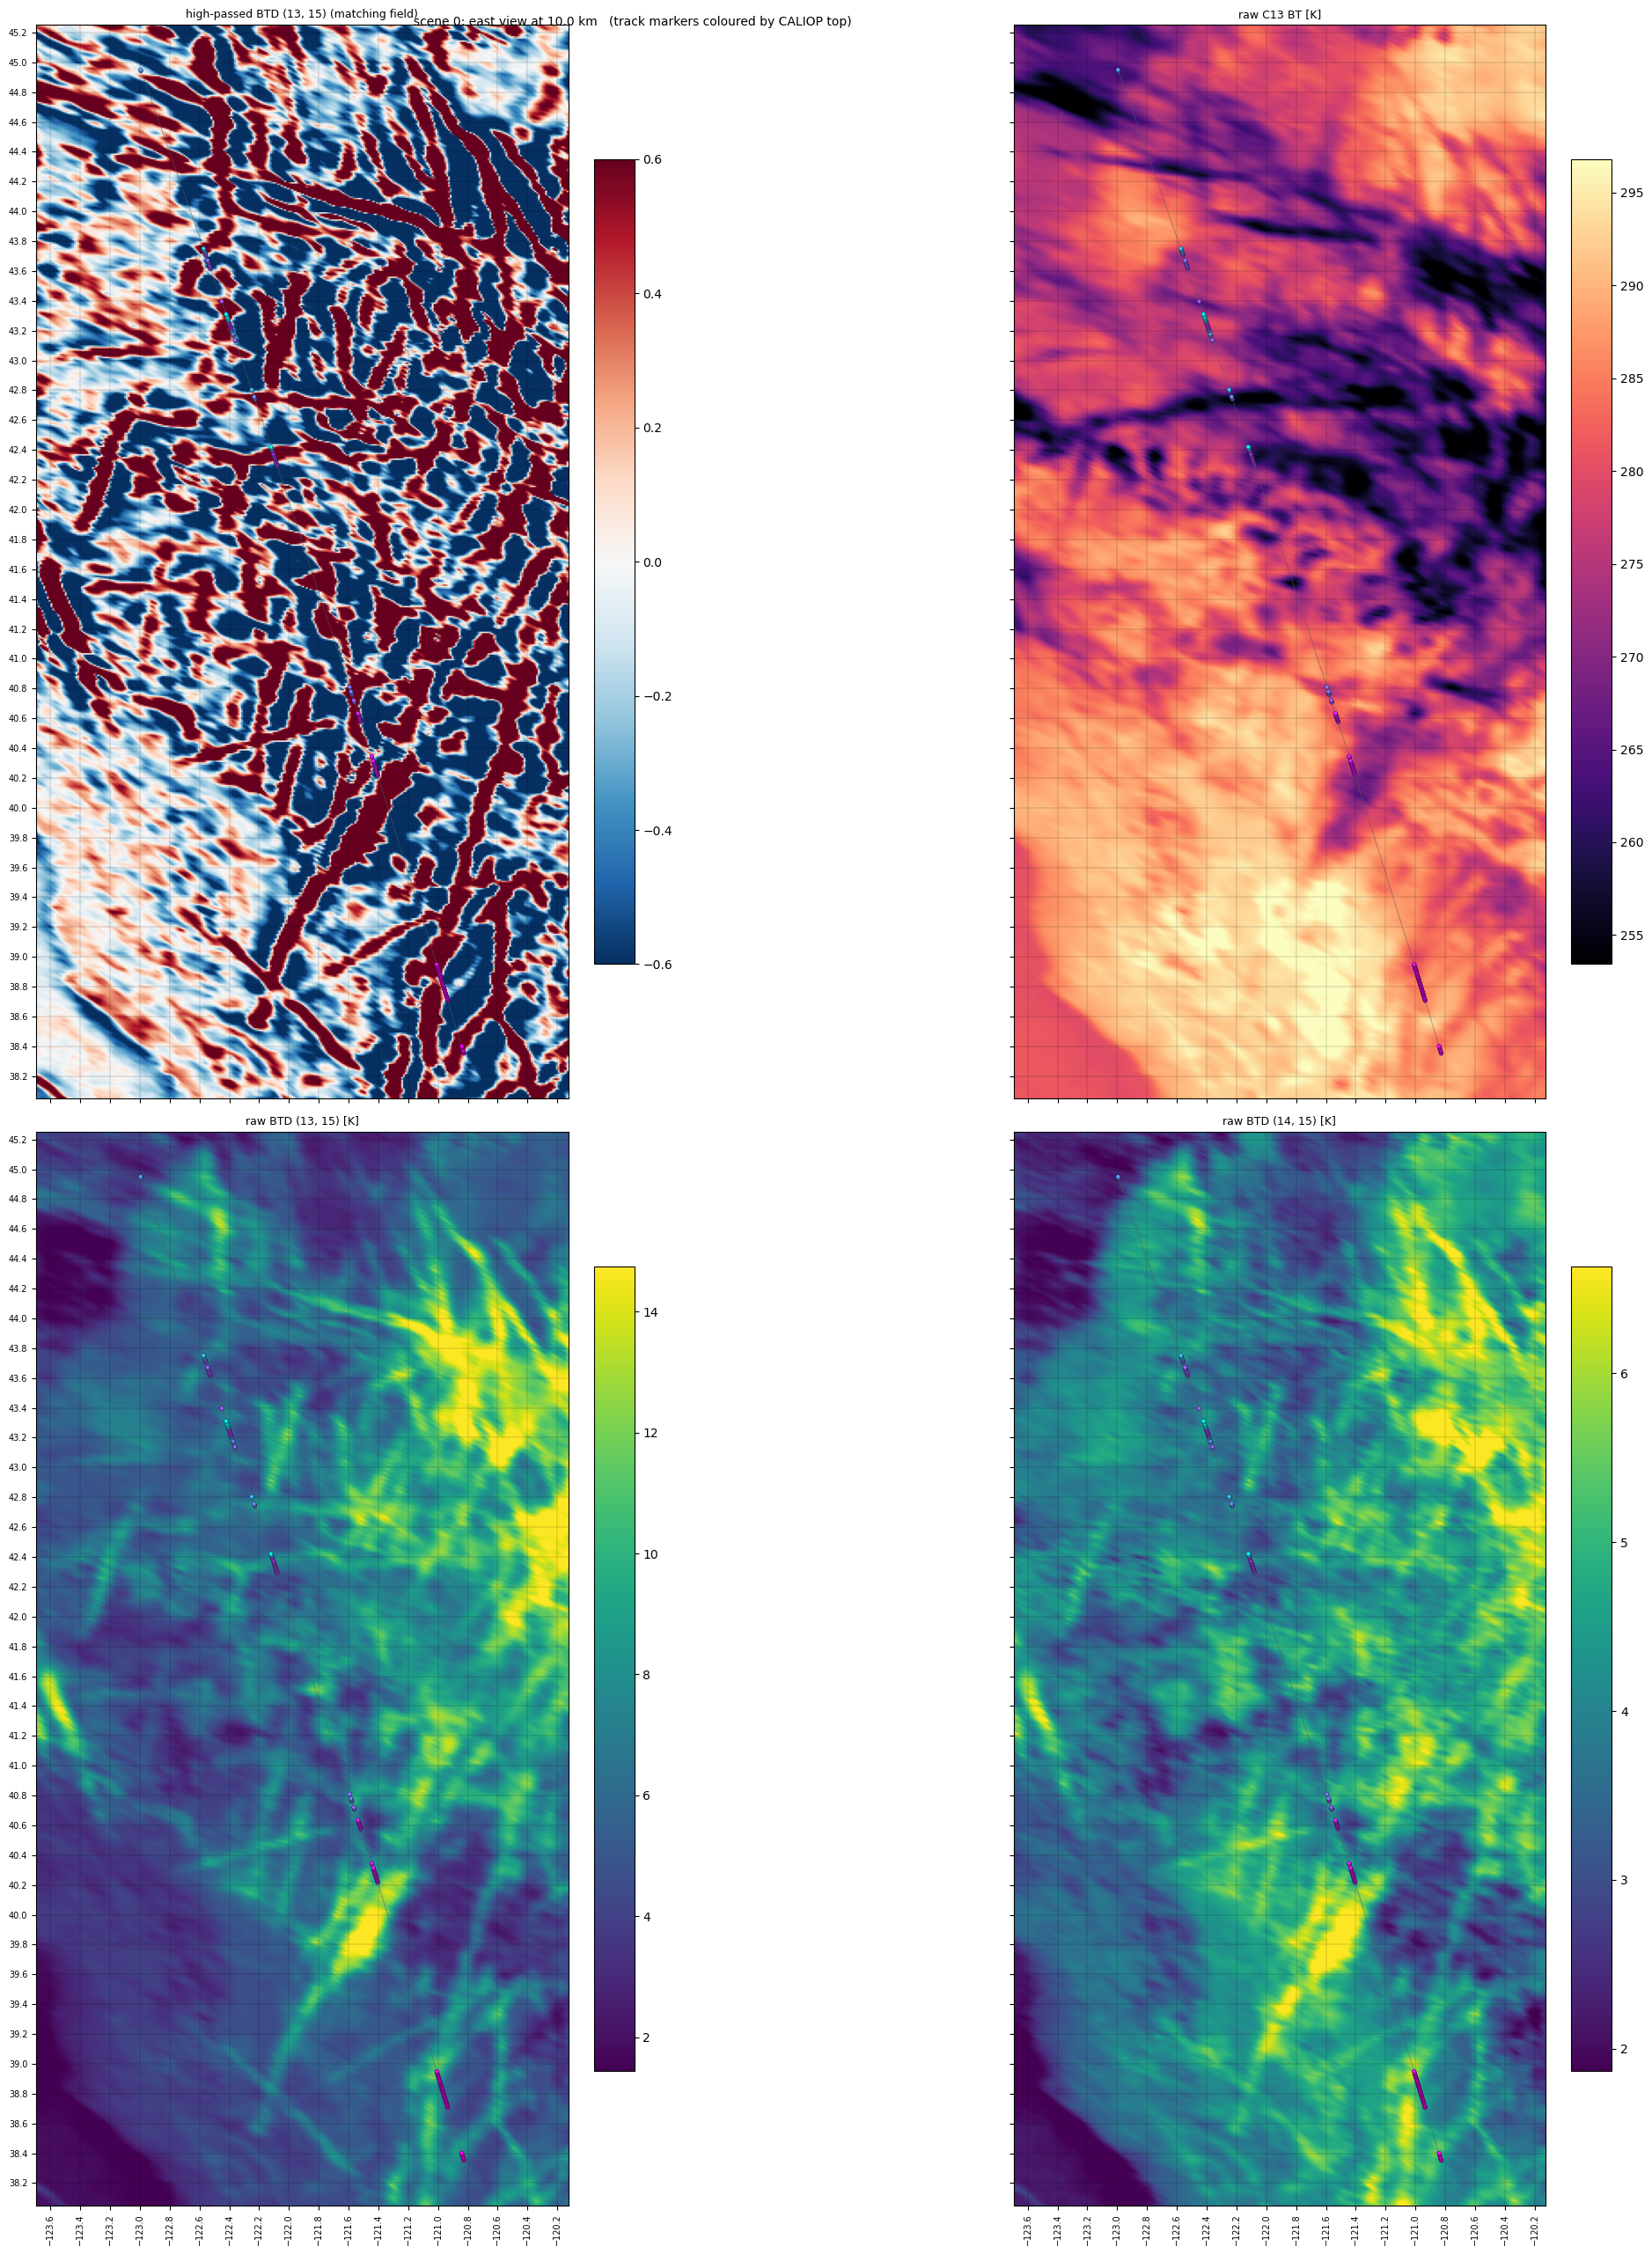

In [200]:
# --- Scene diagnostic: what is actually in this scene -----------------------
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.config import R_EQ, R_POL
from pyproj import Proj

H_REF = float(np.round(rec["h_local"] * 2) / 2) if np.isfinite(rec["h_local"]) else 12.0
A, B = project_pair(H_REF, glat, glon, samplers, sig, cfg,
                    winds=sd.winds, offset_s=sd.offset_s)
ext = [glon.min(), glon.max(), glat.min(), glat.max()]

def raw_sampler(ds):
    """Single-channel CMI sampler on lat/lon (the package's is BTD-only)."""
    pj = ds["goes_imager_projection"]
    H = float(pj.attrs["perspective_point_height"])
    p_ = Proj(proj="geos", h=H, lon_0=float(pj.attrs["longitude_of_projection_origin"]),
              sweep=pj.attrs.get("sweep_angle_axis", "x"), a=R_EQ, b=R_POL)
    d = ds["CMI"].assign_coords(x=ds.x * H, y=ds.y * H)
    def f(la, lo):
        xm, ym = p_(lo, la)
        return d.interp(x=xr.DataArray(xm, dims=("j", "i")),
                        y=xr.DataArray(ym, dims=("j", "i"))).values
    return f

# raw channels sampled at the SAME apparent position as the matching field,
# so every panel is registered to every other
E = cfg.sat_east
alat, alon = apparent_surface_latlon(glat, glon, H_REF * 1e3, SAT_LON[E])
raw = {ch: raw_sampler(sd.fields[E][ch])(alat, alon) for ch in sorted(sd.fields[E])}

pc = lambda Z, a, b: tuple(np.nanpercentile(Z, [a, b]))
panels = [(A, f"high-passed BTD {cfg.match_channels} (matching field)",
           "RdBu_r", (-0.6, 0.6)),
          (raw[13], "raw C13 BT [K]", "magma", pc(raw[13], 1, 99))]
for pair in ((13, 15), (14, 15)):
    if all(c in raw for c in pair):
        Z = raw[pair[0]] - raw[pair[1]]
        panels.append((Z, f"raw BTD {pair} [K]", "viridis", pc(Z, 1, 99)))

ZOOM = None          # e.g. dict(xlim=(-105.6, -105.2), ylim=(43.6, 44.0))

fig, axs = plt.subplots(2, 2, figsize=(26, 26), sharex=True, sharey=True)
v0, v1 = np.percentile(sd.profiles.top_km, [2, 98])
for ax, (Z, ttl, cm, vl) in zip(axs.ravel(), panels):
    im = ax.imshow(Z, origin="lower", extent=ext, cmap=cm, vmin=vl[0], vmax=vl[1])
    plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    ax.plot(sd.profiles.lon, sd.profiles.lat, "-", color="0.35", lw=0.6, alpha=0.6)
    ax.scatter(sd.profiles.lon, sd.profiles.lat, c=sd.profiles.top_km, s=10,
               cmap="cool", vmin=v0, vmax=v1, edgecolor="k", linewidth=0.2, zorder=3)
    ax.set_title(ttl, fontsize=9)
    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.grid(alpha=0.35, color="k", lw=0.35)
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    if ZOOM:
        ax.set_xlim(*ZOOM["xlim"]); ax.set_ylim(*ZOOM["ylim"])

fig.suptitle(f"scene {SCENE}: east view at {H_REF:.1f} km   "
             "(track markers coloured by CALIOP top)", fontsize=10)
plt.tight_layout()

print(f"raw C13 BT median {np.nanmedian(raw[13]):.1f} K")
for pair in ((13, 15), (14, 15)):
    if all(c in raw for c in pair):
        Z = raw[pair[0]] - raw[pair[1]]
        print(f"raw BTD {pair}: median {np.nanmedian(Z):5.2f} K   "
              f"p99 {np.nanpercentile(Z, 99):5.2f} K   "
              f"scene sd {np.nanstd(Z):.2f} K")

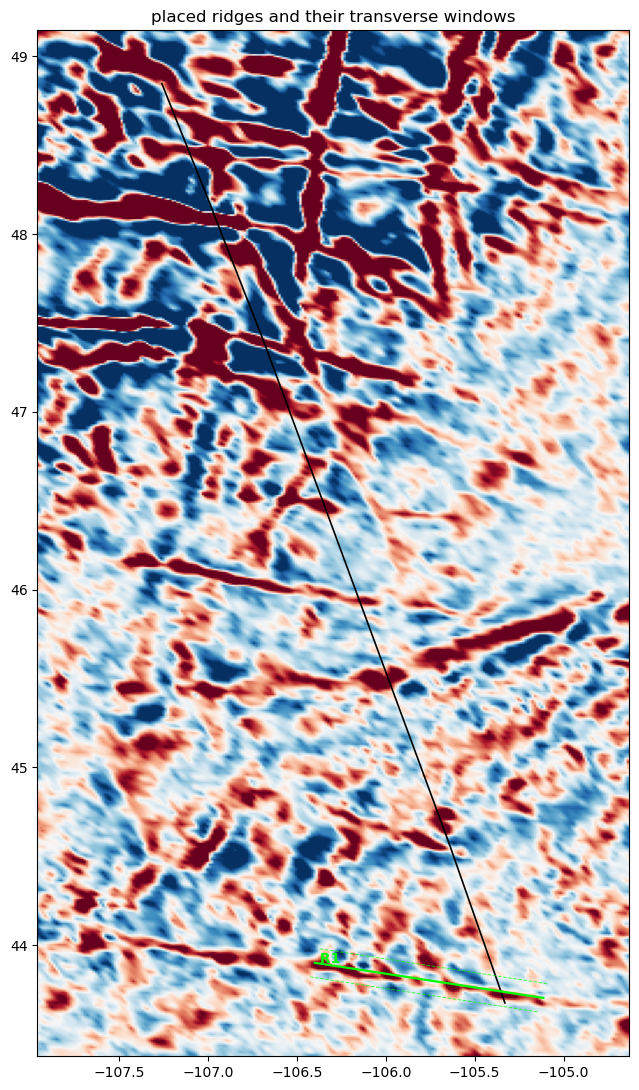

In [123]:

# Ridges for scene 0
"""RIDGES = {
        "R1": [(38.3, -120.85), (38.4, -120.8), (38.5, -120.75)],
        "R2": [(38.3, -121.00), (38.4, -121.0), (38.7, -120.98), (38.8,-120.95), (39.2 ,-120.9)],
        "R3": [(40.1, -121.5), (40.3, -121.4)],
        "R4": [(40.5, -121.5), (40.8, -121.5)],
        "R5": [(40.8, -121.65), (41.0, -121.9)],
        "R6": [(42.35,-121.95), (42.33, -122.1), (42.3, -122.3)],
        "R7": [(42.45,-122.15), (42.7, -122.1)],
        "R8": [(42.75, -122.3), (42.71, -122.0)],
        "R9": [(42.85, -122.3), (42.85, -122.6)],

}"""





# Ridges for scene 8
"""RIDGES = {
    "R1": [(33.47, -115.04), (33.43, -114.90), (33.39, -114.80), (33.35, -114.70), (33.34, -114.6), (33.32, -114.5), (33.27, -114.14)],
    "R2": [(33.75, -115.28), (33.40, -115.12), (33.20, -115.05), (32.80, -114.83)],
    "R3": [(33.08, -114.75), (33.14, -114.90), (33.17, -114.95), (33.26, -115.25)],
    "R4": [(33.63 ,-115.03), (33.80, -115.10), (34.02,-115.20)],
    "R5": [(34.20, -115.25), (34.40, -115.38)]
}"""

# Ridges for scene 12

RIDGES = {
    "R1": [(43.9, -106.4), (43.7, -105.1)]
}


POLARITY = {"R1": +1, "R2": +1, "R3": +1}      # +1 = bright in the high-passed BTD
HALF_KM, BIN_KM = 9.0, 20.0                    # transverse half-width, along-trail bin

RS = {k: resample_ridge(v) for k, v in RIDGES.items()}

fig, ax = plt.subplots(figsize=(9, 11))
ax.imshow(A, origin="lower", extent=ext, cmap="RdBu_r", vmin=-0.6, vmax=0.6)
ax.plot(sd.profiles.lon, sd.profiles.lat, "k-", lw=1.2)
for nm, R in RS.items():
    la, lo = to_ll(R["x"], R["y"])
    ax.plot(lo, la, "-", lw=1.6, color="lime")
    for sgn in (-1, 1):                          # transverse window edges
        lae, loe = to_ll(R["x"] + sgn * HALF_KM * R["nx"],
                         R["y"] + sgn * HALF_KM * R["ny"])
        ax.plot(loe, lae, "--", lw=0.7, color="lime", alpha=0.7)
    ax.text(lo[0], la[0], f" {nm}", color="lime", fontweight="bold")
ax.set_title("placed ridges and their transverse windows")
plt.tight_layout()

### What the geometry says before any matching

The sensitivity is pure geometry. Read this table first: it predicts which
ridges the method can do anything with, and a ridge running close to
$\mathbf{k}$ is unrecoverable no matter how bright it is.

In [124]:
rows = []
for nm, R in RS.items():
    for bn in ridge_bins(R, BIN_KM):
        la, lo = (float(v) for v in to_ll(bn["x"], bn["y"]))
        k = disparity_k(la, lo, H_REF)
        rows.append(dict(ridge=nm, s=bn["s"],
                         bearing=np.degrees(np.arctan2(bn["nx"], bn["ny"])) - 90,
                         sens=k[0] * bn["nx"] + k[1] * bn["ny"]))
geo = pd.DataFrame(rows)
geo["sigma_h_per_100m"] = 0.1 / geo.sens.abs()     # height error for 100 m of offset error
print(geo.groupby("ridge").agg(n_bins=("s", "size"),
                               bearing=("bearing", "mean"),
                               sens=("sens", "mean"),
                               sigma_h_per_100m=("sigma_h_per_100m", "mean")).round(3))
print(f"\n|k| = {np.hypot(*k0):.3f} km per km, azimuth "
      f"{np.degrees(np.arctan2(k0[1], k0[0])):.1f} deg")

       n_bins  bearing   sens  sigma_h_per_100m
ridge                                          
R1          5  -77.046 -0.498             0.201

|k| = 2.448 km per km, azimuth 179.8 deg


## 8. Arm 2 — ribbon correlation (the control)

The same plane sweep as the baseline, but with the correlation support masked to
the ridge strip instead of a 25 km box. Support changed, estimator unchanged.

In [125]:
def ribbon_arm(ridges, h_ref, half_km=HALF_KM, bin_km=BIN_KM,
               dh_max=3.0, dh_km=0.25):
    """Arm 2: masked-correlation height sweep over ridge-following strips."""
    masks = []
    for nm, R in ridges.items():
        for bn in ridge_bins(R, bin_km):
            dx, dy = X - bn["x"], Y - bn["y"]
            tn = (-bn["ny"], bn["nx"])
            masks.append((nm, bn["s"],
                          (np.abs(dx * bn["nx"] + dy * bn["ny"]) <= half_km)
                          & (np.abs(dx * tn[0] + dy * tn[1]) <= bin_km / 2)))
    hs = np.arange(h_ref - dh_max, h_ref + dh_max + 1e-9, dh_km)
    Cm = np.full((hs.size, len(masks)), np.nan)
    for q, h in enumerate(hs):
        Ah, Bh = project_pair(h, glat, glon, samplers, sig, cfg,
                              winds=sd.winds, offset_s=sd.offset_s)
        ok = np.isfinite(Ah) & np.isfinite(Bh)
        for p, (_, _, m) in enumerate(masks):
            mm = m & ok
            if mm.sum() > 50:
                Cm[q, p] = np.corrcoef(Ah[mm], Bh[mm])[0, 1]
    out = []
    for p, (nm, s, m) in enumerate(masks):
        c = Cm[:, p]
        if not np.isfinite(c).any():
            continue
        h, r, sg = refine_peak(hs, c, hs[int(np.nanargmax(c))], halfwidth=0.75)
        out.append(dict(ridge=nm, s=s, n_px=int(m.sum()),
                        h_ribbon=h, r_ribbon=r, sigma_ribbon=sg))
    return pd.DataFrame(out)

## 9. Run all three arms at the same locations

In [126]:
rows, keep = [], {}
for nm, R in RS.items():
    for r in ridge_arm(A, B, R, H_REF, half_km=HALF_KM, bin_km=BIN_KM,
                       polarity=POLARITY.get(nm, 1)):
        keep[(nm, r["s"])] = r                       # profiles/curves for plotting
        rows.append(dict(ridge=nm, **{k: v for k, v in r.items()
                                      if k not in ("profA", "profB", "sn",
                                                   "lam", "rcurve")},
                         h_win=float(sample(Hq, r["lat"], r["lon"])[0]),
                         r_win=float(sample(rmax, r["lat"], r["lon"])[0])))

df = (pd.DataFrame(rows)
      .merge(ribbon_arm(RS, H_REF), on=["ridge", "s"], how="left")
      .rename(columns={"h": "h_ridge", "r": "r_ridge"}))

pd.set_option("display.width", 200)
print(df[["ridge", "s", "lat", "lon", "sens", "d_perp", "h_ridge", "sigma_h",
          "r_ridge", "h_ribbon", "r_ribbon", "h_win", "r_win", "amp"]]
      .round(3).to_string(index=False))

ridge    s    lat      lon   sens  d_perp  h_ridge  sigma_h  r_ridge  h_ribbon  r_ribbon  h_win  r_win   amp
   R1  9.0 43.882 -106.282 -0.494   0.536    8.916    0.102    0.959    13.000     0.529 14.022  0.520 0.821
   R1 29.0 43.841 -106.019 -0.496  -0.533   11.075    0.104    0.994     9.794     0.483  9.258  0.480 0.549
   R1 49.0 43.801 -105.757 -0.498   0.098    9.802    0.107    0.850     8.843     0.499  9.053  0.506 0.232
   R1 69.0 43.761 -105.494 -0.500   0.241    9.518    0.068    0.988     8.285     0.731  9.015  0.675 0.570
   R1 89.0 43.720 -105.232 -0.501  -0.227   10.452    0.178    0.942    10.411     0.625    NaN  0.602 0.599


In [127]:
summary = df.groupby("ridge").apply(lambda g: pd.Series({
    "n_bins":      len(g),
    "|sens|":      g.sens.abs().mean(),
    "ridge_med":   g.h_ridge.median(),
    "ridge_sd":    g.h_ridge.std(),
    "ribbon_med":  g.h_ribbon.median(),
    "ribbon_sd":   g.h_ribbon.std(),
    "window_med":  g.h_win.median(),
    "window_sd":   g.h_win.std(),
    "ridge-window": (g.h_ridge - g.h_win).median(),
}), include_groups=False).round(3)
print(summary.to_string())
print("\nalong-ridge sd is the truth-free precision metric: a single contrail")
print("should be near-constant in height, so scatter along it is mostly error.")

       n_bins  |sens|  ridge_med  ridge_sd  ribbon_med  ribbon_sd  window_med  window_sd  ridge-window
ridge                                                                                                 
R1        5.0   0.498      9.802     0.836       9.794      1.835       9.155      2.459         0.626

along-ridge sd is the truth-free precision metric: a single contrail
should be near-constant in height, so scatter along it is mostly error.


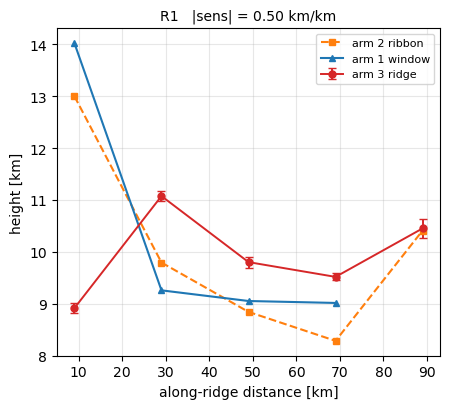

In [128]:
fig, axs = plt.subplots(1, len(RS), figsize=(4.6 * len(RS), 4.2))
axs = np.atleast_1d(axs)
for ax, (nm, g) in zip(axs, df.groupby("ridge")):
    ax.errorbar(g.s, g.h_ridge, yerr=g.sigma_h, fmt="o-", color="C3",
                ms=5, lw=1.4, capsize=3, label="arm 3 ridge")
    ax.plot(g.s, g.h_ribbon, "s--", color="C1", ms=5, label="arm 2 ribbon")
    ax.plot(g.s, g.h_win, "^-", color="C0", ms=5, label="arm 1 window")
    ax.set_title(f"{nm}   |sens| = {g.sens.abs().mean():.2f} km/km", fontsize=10)
    ax.set_xlabel("along-ridge distance [km]")
    ax.grid(alpha=0.3)
axs[0].set_ylabel("height [km]")
axs[0].legend(fontsize=8)
plt.tight_layout()

### Look at the profiles

Anything surprising in the numbers should be visible here first: the pair of
averaged transverse profiles, and the lag curve whose peak is the measurement.
A broad, flat, or double-peaked lag curve is the tell for a bad bin.

IndexError: index 1 is out of bounds for axis 0 with size 1

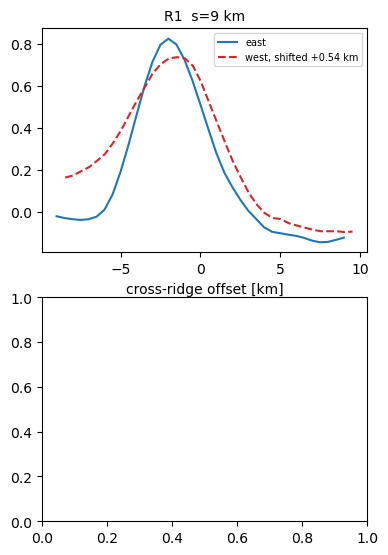

In [130]:
PICK = [next(k for k in keep if k[0] == nm) for nm in RS]   # one bin per ridge
fig, axs = plt.subplots(2, len(PICK), figsize=(4.2 * len(PICK), 6.4))
axs = np.atleast_2d(axs)
for c, key in enumerate(PICK):
    r = keep[key]
    axs[0, c].plot(r["sn"], r["profA"], color="C0", label="east")
    axs[0, c].plot(r["sn"] + r["d_perp"], r["profB"], color="C3", ls="--",
                   label=f"west, shifted {r['d_perp']:+.2f} km")
    axs[0, c].set_title(f"{key[0]}  s={key[1]:.0f} km", fontsize=10)
    axs[0, c].set_xlabel("cross-ridge offset [km]")
    axs[0, c].legend(fontsize=7)
    h_of_lam = H_REF + r["lam"] / r["sens"]
    axs[1, c].plot(h_of_lam, r["rcurve"], color="k")
    axs[1, c].axvline(r["h"], color="C3", ls=":")
    axs[1, c].set_xlabel("implied height [km]")
    axs[1, c].set_ylabel("r")
    for ax in axs[:, c]:
        ax.grid(alpha=0.3)
axs[0, 0].set_ylabel("high-passed BTD [K]")
plt.tight_layout()

## 10. Checks

**(a) Reference-height sensitivity.** The inversion is linear, so the retrieved
height should not depend on where the sweep was centred. Residual dependence is
the appearance of the ridge changing between projections, not the geometry.

**(b) Truth, where there is any.** A hand-placed ridge rarely crosses the CALIOP
track. Bins with profiles within `D_MAX` km get a truth comparison; everything
else is method-versus-method only. Expect one or two truth points per scene —
which is precisely why this needs a case-study campaign rather than one scene.

In [131]:
print("(a) reference-height sensitivity")
for href in (H_REF - 2.0, H_REF, H_REF + 1.5):
    Ah, Bh = project_pair(href, glat, glon, samplers, sig, cfg,
                          winds=sd.winds, offset_s=sd.offset_s)
    out = {nm: np.nanmedian([x["h"] for x in
                             ridge_arm(Ah, Bh, R, href, half_km=HALF_KM,
                                       bin_km=BIN_KM, polarity=POLARITY.get(nm, 1))])
           for nm, R in RS.items()}
    print(f"  h_ref={href:5.2f}  " + "  ".join(f"{k}={v:.3f}" for k, v in out.items()))

(a) reference-height sensitivity
  h_ref= 8.00  R1=10.193
  h_ref=10.00  R1=9.802
  h_ref=11.50  R1=9.943


In [132]:
D_MAX = 8.0
tx, ty = to_km(sd.profiles.lat.values, sd.profiles.lon.values)
top = sd.profiles.top_km.values

tr = []
for _, r in df.iterrows():
    x, y = to_km(r.lat, r.lon)
    d = np.hypot(tx - x, ty - y)
    m = d < D_MAX
    if m.sum() >= 3:
        tr.append(dict(ridge=r.ridge, s=r.s, d_min=d.min(), n_prof=int(m.sum()),
                       caliop=top[m].mean(), caliop_sd=top[m].std(),
                       err_ridge=r.h_ridge - top[m].mean(),
                       err_ribbon=r.h_ribbon - top[m].mean(),
                       err_window=r.h_win - top[m].mean()))
tr = pd.DataFrame(tr)
if len(tr):
    print(tr.round(3).to_string(index=False))
    print("\nscene-wide baseline for reference: map_bias "
          f"{rec['map_bias']:+.3f}, map_scatter {rec['map_scatter']:.3f} "
          f"over {rec['map_n']} profiles")
else:
    print(f"no ridge bin within {D_MAX} km of the track - no truth on this scene")

no ridge bin within 8.0 km of the track - no truth on this scene


31 of 161 profiles fall inside a ridge ribbon, in 1 crossings
       lat0    lat1   n  caliop  window  ribbon   ridge
lat                                                    
0    43.674  43.763  31   9.462   9.176   9.598  10.095

common subset: n=31 profiles in 1 crossings (effective n is the number of crossings, not profiles)
  window  bias -0.285  sd 0.608  rmse 0.672
  ribbon  bias +0.136  sd 0.577  rmse 0.593
  ridge   bias +0.633  sd 0.611  rmse 0.880


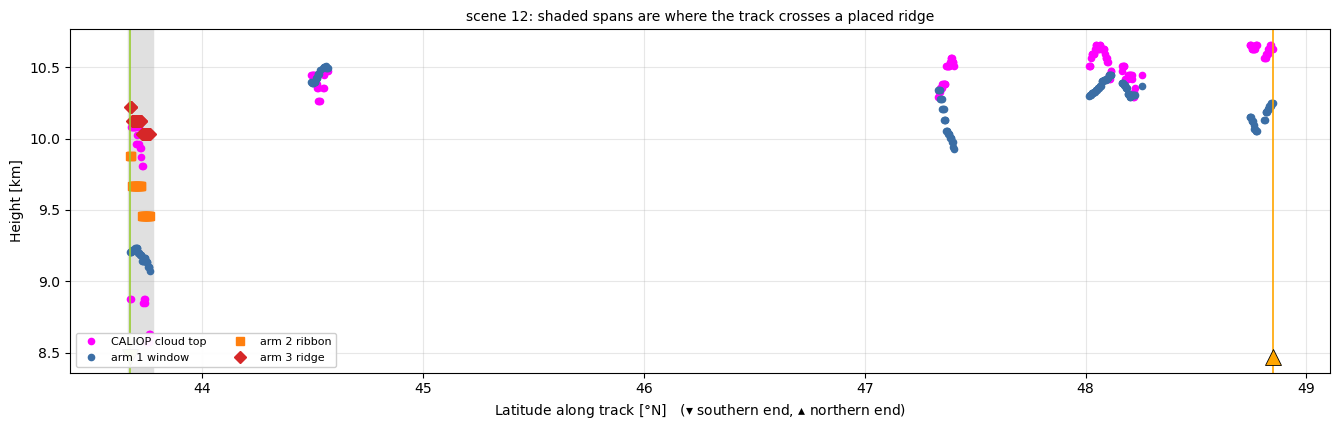

In [133]:
# --- Ridge-restricted "map product" -----------------------------------------
def paint_ridges(df, RS, half_km=HALF_KM, hcol="h_ridge"):
    """Per-bin heights -> an Hq-shaped field defined only on the ridge ribbons.
    Overlapping ribbons resolve in favour of the nearer centreline."""
    H = np.full(glat.shape, np.nan); S = np.full(glat.shape, np.nan)
    W = np.full(glat.shape, np.inf)
    for nm, R in RS.items():
        g = df[df.ridge == nm].sort_values("s")
        if g[hcol].notna().sum() < 2:
            continue
        d2 = (X[..., None] - R["x"]) ** 2 + (Y[..., None] - R["y"]) ** 2
        kmin = np.argmin(d2, axis=-1)
        dmin = np.sqrt(np.take_along_axis(d2, kmin[..., None], -1)[..., 0])
        m = ((kmin > 0) & (kmin < R["s"].size - 1)          # no end caps
             & (dmin <= half_km) & (dmin < W))
        H[m] = np.interp(R["s"][kmin][m], g.s.values, g[hcol].values)
        S[m] = R["s"][kmin][m]; W[m] = dmin[m]
    return H, S

def patch_median(Z, lat, lon, k=2):
    """5x5 patch median, matching how run_scene samples Hq at a profile."""
    i = np.searchsorted(LA, lat).clip(k, glat.shape[0] - k - 1)
    j = np.searchsorted(LO, lon).clip(k, glat.shape[1] - k - 1)
    return np.array([np.nanmedian(Z[ii-k:ii+k+1, jj-k:jj+k+1])
                     if np.isfinite(Z[ii-k:ii+k+1, jj-k:jj+k+1]).any() else np.nan
                     for ii, jj in zip(i, j)])

H_ridge_map, S_map = paint_ridges(df, RS, hcol="h_ridge")
H_ribbon_map, _    = paint_ridges(df, RS, hcol="h_ribbon")

trk = prof.sort_values("lat").copy()
trk["h_ridge"]  = patch_median(H_ridge_map,  trk.lat.values, trk.lon.values)
trk["h_ribbon"] = patch_median(H_ribbon_map, trk.lat.values, trk.lon.values)

on  = trk[trk.h_ridge.notna()]
seg = (on.lat.diff().fillna(0) > 0.05).cumsum()          # contiguous crossings
print(f"{len(on)} of {len(trk)} profiles fall inside a ridge ribbon, "
      f"in {seg.nunique()} crossings")
print(on.groupby(seg).agg(lat0=("lat","min"), lat1=("lat","max"), n=("lat","size"),
                          caliop=("top_km","mean"), window=("h_map","mean"),
                          ribbon=("h_ribbon","mean"), ridge=("h_ridge","mean")
                          ).round(3).to_string())

fig, ax = plt.subplots(figsize=(13.5, 4.4))
for _, gg in on.groupby(seg):
    ax.axvspan(gg.lat.min() - 0.012, gg.lat.max() + 0.012, color="0.88", zorder=0)
ax.plot(trk.lat, trk.top_km,   "o", ms=4.5, color="magenta", label="CALIOP cloud top")
ax.plot(trk.lat, trk.h_map,    "o", ms=4.5, color="#3b6ea5", label="arm 1 window")
ax.plot(trk.lat, trk.h_ribbon, "s", ms=6, ls="none", color="C1", label="arm 2 ribbon")
ax.plot(trk.lat, trk.h_ridge,  "D", ms=6, ls="none", color="C3", label="arm 3 ridge")

lo, hi = trk.lat.min(), trk.lat.max()
ax.axvline(lo, color="yellowgreen", lw=1.2); ax.axvline(hi, color="orange", lw=1.2)
y0 = ax.get_ylim()[0]
ax.plot([lo], [y0], "v", ms=11, color="yellowgreen", mec="k", mew=0.6, clip_on=False)
ax.plot([hi], [y0], "^", ms=11, color="orange", mec="k", mew=0.6, clip_on=False)
ax.set_xlabel("Latitude along track [$\\degree$N]   "
              "($\\blacktriangledown$ southern end, $\\blacktriangle$ northern end)")
ax.set_ylabel("Height [km]"); ax.grid(alpha=0.3)
ax.legend(loc="lower left", fontsize=8, ncol=2, framealpha=0.95)
ax.set_title(f"scene {SCENE}: shaded spans are where the track crosses a placed ridge",
             fontsize=10)
plt.tight_layout()

sub = trk.dropna(subset=["h_ridge", "h_map"])
print(f"\ncommon subset: n={len(sub)} profiles in {seg.nunique()} crossings "
      f"(effective n is the number of crossings, not profiles)")
for c, lab in (("h_map","window"), ("h_ribbon","ribbon"), ("h_ridge","ridge")):
    e = (sub[c] - sub.top_km).values
    print(f"  {lab:7s} bias {e.mean():+.3f}  sd {e.std():.3f}  "
          f"rmse {np.sqrt((e**2).mean()):.3f}")

## 11. Case-study record

Fill this in per scene and append to a running table. The verdict criteria
below were fixed before the scene-8 run.

**Pre-registered criteria.** Arm 3 is worth promoting if, over *at least five
scenes*:

1. along-ridge sd (arm 3) < along-ridge sd (arm 1) by >20% on bins with
   $|s| \ge 1.0$ km/km, **and**
2. the arm-3 vs arm-1 median difference stays within ±0.2 km (no new bias), **and**
3. where truth exists, arm-3 error is no worse than arm 1.

If (1) holds only because arm 2 also improves, the gain is support, not
estimator — record that, and the cheaper change is to mask the existing window.

**Findings from fixture scene 8** (kept as the first row, not as a conclusion):

- On the two well-oriented ridges ($|s| = 1.59$, $1.77$) all three arms agree to
  within 0.02 km in the median, and along-ridge sd is comparable or slightly
  *worse* for arm 3 (0.070 / 0.121 km against the window's 0.059 / 0.085). On a
  scene where the window baseline is already near its ceiling, the ridge
  estimator reproduces it and buys nothing. Useful mutual validation; a null on
  the lever.
- The near-E–W ridge R3 ($|s|$ falling to 0.17) fails in arm 3 — +2.4 km at the
  eastern end — while arms 1 and 2 stay flat. The aperture problem here is
  imposed by *averaging along the trail*, not by the ridge: arm 2 keeps the
  along-trail texture that restores sensitivity, arm 3 throws it away for the
  $\sqrt{N}$ transverse gain. For a badly oriented trail that trade is a loss.
- Neither `r` (0.98–1.0 on the failing bins) nor `sigma_h` (0.06–0.16 km against
  discrepancies up to 2.4 km) flags R3. The only thing that does is $|s|$, which
  is known *before* matching. **Gate on the geometry, not on the fit.** Same
  pattern as the map product, where r_map does not select for accuracy.
- Reference-height sensitivity is 0.04 km (R1) and 0.09 km (R2) over
  $h_{ref} \in [11, 14.5]$, but 0.3 km for R3 — the residual $h_{ref}$
  dependence tracks the sensitivity, as it should.
- Two bins fall within 8 km of the track; arm-3 errors there are −0.16 and
  −0.08 km against a scene-wide map_scatter of 0.39. Encouraging, and worth
  nothing at n = 2.
- Side observation from the profile plot: the east view's ridge amplitude
  exceeds the west's (~6.5 vs ~4.5 K) despite east being the *more* oblique view
  (VZA 57.7 vs 45.7), so this is not the footprint. Slant-path optical depth is
  the obvious candidate. Left open — but a systematic shape asymmetry between
  the views is exactly what biases a correlation lag, so it belongs on the list.

## 12. Not implemented: automated ridge detection

Deliberately out of scope until the manual comparison has a verdict over several
scenes. What a detector would have to supply, given what the manual arm needs:

- **An ordered centreline**, not a mask. The estimator needs $\hat{n}$ per bin;
  a per-pixel probability map has to be thinned and traced first.
- **Orientation accuracy**, which is the binding requirement. Position error in
  the polyline costs almost nothing; orientation error propagates into both
  $\delta_\perp$ and $s$.
- **Separation of adjacent trails**, so the bounded lag search does not
  straddle two crests — the trail spacing on this scene is comparable to the
  transverse window.
- **Polarity and amplitude**, to set the sign and to gate weak bins.

Two routes, in the order worth trying: a classical ridge filter (Frangi /
Steger, i.e. Hessian eigenvector tracing on the high-passed BTD, which gives
sub-pixel centrelines and orientation directly), and the existing contrail
detector, whose masks would still need thinning and tracing. The classical route
is truth-free, which preserves the property that makes this method worth having
over a CALIOP-trained CNN.

Before any of that: run this notebook on scenes 0, 12, 41 and 46, then on
scenes where the window arm actually fails (`low_r`, fragmented cirrus,
high VZA). Scene 8 cannot distinguish the arms because nothing is wrong with the
baseline here.